# Module 5 - Activity - Discussion Group A
## EN.705.623.81.SP26 - AI Algorithm Design and Analysis

**Student:** Akira Hanada  
**Date:** February 21, 2026  
**Topic:** Probabilistic Algorithms and Bayesian Networks

This notebook addresses three problems from Module 5, covering the foundational concepts of Bayesian network structure and factorization (Lecture 5A), exact inference algorithms including Variable Elimination and Junction Tree (Lecture 5B), and approximate inference via rejection sampling (Lecture 5C). Each question is accompanied by detailed explanations, Python code with line-by-line commentary, and visualizations that illustrate the underlying computations.

In [57]:
# Import required libraries for computation and visualization
import numpy as np                          # Numerical operations and random sampling
import pandas as pd                         # Structured data tables for displaying results
import matplotlib.pyplot as plt             # Creating charts and diagrams
import matplotlib.patches as mpatches       # Drawing shapes (circles, arrows) for DAG diagrams
from IPython.display import display           # Enhanced notebook output formatting
import warnings                             # Suppress unnecessary warnings
warnings.filterwarnings('ignore')           # Keep output clean

# Configure pandas display options for full visibility of table content
pd.set_option('display.max_rows', None)     # Show all rows in DataFrames
pd.set_option('display.max_columns', None)  # Show all columns in DataFrames
pd.set_option('display.width', None)        # Auto-detect display width
pd.set_option('display.max_colwidth', None) # Show full cell content without truncation

# Set default visualization style for professional-looking plots
plt.style.use('seaborn-v0_8-darkgrid')      # Seaborn style with grid background
plt.rcParams['figure.figsize'] = (14, 8)    # Default figure size (width, height) in inches
plt.rcParams['font.size'] = 11              # Default font size for readability

# Display library versions to confirm the environment
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print("Libraries imported successfully!")

NumPy version: 2.4.2
Pandas version: 3.0.0
Libraries imported successfully!


---
## Question 1: Intelligent Smoke Detection (Lecture 5A)

An engineering team is building a probabilistic monitoring system for a smart building with four binary variables: **F** (Fire), **S** (Smoke), **A** (Alarm), and **W** (Sprinkler). The DAG structure shows that Fire (F) is the root node with directed edges to Smoke (S), Sprinkler (W), and Alarm (A). In addition, Smoke (S) also has a directed edge into Alarm (A). This means Alarm has two parents: F and S. Note that Sprinkler (W) does **not** have a directed edge into Alarm.

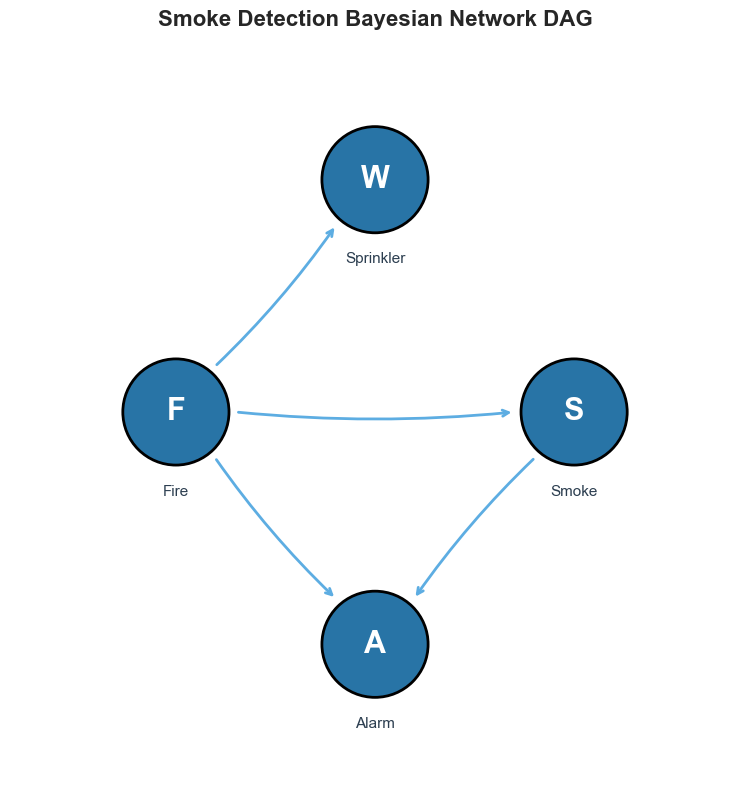

In [58]:
# =============================================================================
# Visualization: Smoke Detection Bayesian Network DAG
# =============================================================================
# This code draws the directed acyclic graph (DAG) for the smoke detection
# system so that the reader can see the dependency structure at a glance.

fig, ax = plt.subplots(figsize=(8, 8))  # Create a square figure for the DAG

# Define node positions in (x, y) coordinates for clear layout
positions = {
    'F': (0.2, 0.5),   # Fire on the left (root cause)
    'W': (0.5, 0.85),  # Sprinkler at top-center
    'S': (0.8, 0.5),   # Smoke on the right
    'A': (0.5, 0.15),  # Alarm at the bottom (effect of multiple parents)
}

# Full names for labeling each node in the legend
full_names = {'F': 'Fire', 'W': 'Sprinkler', 'S': 'Smoke', 'A': 'Alarm'}

# Draw each node as a filled circle with its letter label
for node, (x, y) in positions.items():
    circle = plt.Circle((x, y), 0.08, color='#2874A6', ec='black', lw=2, zorder=5)
    ax.add_patch(circle)                                   # Add circle to axes
    ax.text(x, y, node, ha='center', va='center',          # Place letter in center
            fontsize=22, fontweight='bold', color='white', zorder=6)
    ax.text(x, y - 0.12, full_names[node], ha='center',    # Place full name below
            va='center', fontsize=11, color='#2C3E50')

# Define directed edges as (source, target) pairs matching the DAG in Picture1
edges = [
    ('F', 'W'),  # Fire influences Sprinkler activation
    ('F', 'S'),  # Fire causes Smoke
    ('F', 'A'),  # Fire can directly trigger Alarm
    ('S', 'A'),  # Smoke presence contributes to Alarm
]

# Draw each edge as an arrow from source to target
for src, tgt in edges:
    x1, y1 = positions[src]   # Starting coordinates
    x2, y2 = positions[tgt]   # Ending coordinates
    # Compute direction vector and shorten arrow so it doesn't overlap circles
    dx, dy = x2 - x1, y2 - y1
    length = np.sqrt(dx**2 + dy**2)          # Euclidean distance between centers
    shrink = 0.09                             # Offset to stop arrow at circle edge
    ax.annotate('', xy=(x2 - shrink*dx/length, y2 - shrink*dy/length),   # Arrow tip
                xytext=(x1 + shrink*dx/length, y1 + shrink*dy/length),   # Arrow tail
                arrowprops=dict(arrowstyle='->', color='#5DADE2',
                                lw=2, connectionstyle='arc3,rad=0.05'))

ax.set_xlim(-0.05, 1.05)   # Horizontal axis range
ax.set_ylim(-0.05, 1.05)   # Vertical axis range
ax.set_aspect('equal')      # Equal scaling so circles look round
ax.axis('off')              # Hide axes for a clean diagram
ax.set_title('Smoke Detection Bayesian Network DAG', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### (a) Factorized Joint Distribution

According to the Bayesian network factorization theorem, the joint probability distribution over all variables equals the product of each variable's conditional probability given its parent nodes in the DAG (Russell & Norvig, 2021, Chapter 13). The lecture (Chen, 2026a) states the general formula as $P(X_1, \dots, X_n) = \prod_{i=1}^{n} P(X_i \mid \text{Parents}(X_i))$. Reading the parents of each node from the DAG:

| Variable | Parents in DAG | Local Factor |
|----------|---------------|--------------|
| F (Fire) | None | $P(F)$ |
| S (Smoke) | F | $P(S \mid F)$ |
| W (Sprinkler) | F | $P(W \mid F)$ |
| A (Alarm) | F, S | $P(A \mid F, S)$ |

Therefore, the factorized joint distribution is:

$$P(F, S, A, W) = P(F) \cdot P(S \mid F) \cdot P(W \mid F) \cdot P(A \mid F, S)$$

This factorization captures all four variables with only local conditional distributions rather than one monolithic joint table. Each factor involves only the variable and its direct parents, which mirrors the causal structure of the real-world system: fire is the root cause that directly influences whether smoke appears, whether sprinklers activate, and whether the alarm sounds, while the alarm also depends on fire and the smoke state. Note that Sprinkler (W) is not a parent of Alarm in this DAG — the alarm responds to fire and smoke but not directly to the sprinkler. This is precisely the computational advantage that Bayesian networks provide over brute-force joint distribution representations, as emphasized in the lecture materials (Chen, 2026a).

In [59]:
# =============================================================================
# Table: Factorization Summary for Question 1(a)
# =============================================================================
# Create a structured table showing each variable, its parents, and the
# corresponding local conditional probability factor.

factorization_data = {
    'Variable': ['F (Fire)', 'S (Smoke)', 'W (Sprinkler)', 'A (Alarm)'],
    'Parents': ['None (root)', 'F', 'F', 'F, S'],
    'Local Factor': ['P(F)', 'P(S | F)', 'P(W | F)', 'P(A | F, S)'],
    'Table Size (binary)': ['2', '2 × 2 = 4', '2 × 2 = 4', '2 × 2 × 2 = 8'],
    'Free Parameters': ['1', '2', '2', '4']
}

df_fact = pd.DataFrame(factorization_data)  # Create DataFrame from dictionary
print("Factorized Joint Distribution Components:")
print("=" * 60)
display(df_fact.style.hide(axis='index').set_properties(**{'text-align': 'left'}))  # Render as HTML table
print("\nJoint:  P(F, S, A, W) = P(F) · P(S|F) · P(W|F) · P(A|F,S)")

Factorized Joint Distribution Components:


Variable,Parents,Local Factor,Table Size (binary),Free Parameters
F (Fire),None (root),P(F),2,1
S (Smoke),F,P(S | F),2 × 2 = 4,2
W (Sprinkler),F,P(W | F),2 × 2 = 4,2
A (Alarm),"F, S","P(A | F, S)",2 × 2 × 2 = 8,4



Joint:  P(F, S, A, W) = P(F) · P(S|F) · P(W|F) · P(A|F,S)


### (b) Bayes' Rule: Computing P(F = True | A = True)

Computing $P(F = \text{True} \mid A = \text{True})$ means we want to update our belief about whether a fire is actually occurring, given that we have observed the alarm sounding. This is a classic application of Bayes' rule, which the lecture describes as "the mathematical engine of probabilistic inference" (Chen, 2026a). The formula is:

$$P(F = \text{True} \mid A = \text{True}) = \frac{P(A = \text{True} \mid F = \text{True}) \cdot P(F = \text{True})}{P(A = \text{True})}$$

Each component plays a specific role in the belief update. The **prior** $P(F = \text{True})$ represents our initial belief about the probability of fire before hearing the alarm. In most buildings, fires are rare events, so this prior is small — perhaps 0.001 or even less. The **likelihood** $P(A = \text{True} \mid F = \text{True})$ measures how probable it is that the alarm would ring if there truly were a fire; a well-maintained alarm system should have a high likelihood close to 1.0. The **evidence** $P(A = \text{True})$ is the total probability of the alarm sounding across all possible scenarios — both genuine fires and false alarms — and serves as a normalizing constant.

The critical insight, as illustrated by the fire alarm example in the lecture (Chen, 2026a), is that even when the alarm is highly accurate (say 99% detection rate for real fires), the posterior probability of an actual fire may still be surprisingly low because fires are extremely rare. This demonstrates the base-rate effect: the prior probability heavily influences the posterior. In the lecture example, despite a 99% accurate alarm, the posterior probability of fire given the alarm was only about 5%. The belief being updated is our degree of confidence that the cause (fire) is present, given the observation (alarm). We shift from a prior based solely on base rates to a posterior that incorporates the new evidence. This is fundamentally what Bayesian inference does: it rationally combines what we already believed with what we have just observed, producing a revised belief that accounts for both sources of information (Russell & Norvig, 2021, Chapter 13).

Bayes' Rule Calculation: P(F = True | A = True)


Component,Value,Interpretation
Prior P(F),0.0010,"Fires are rare — 1 in 1,000 days"
Likelihood P(A|F),0.9900,Alarm is 99% reliable when fire is present
False Alarm P(A|¬F),0.0200,Alarm falsely rings 2% of the time
Evidence P(A),0.02097,Total probability alarm sounds (any cause)
Posterior P(F|A),0.0472,Only ~4.7% chance of real fire given alarm


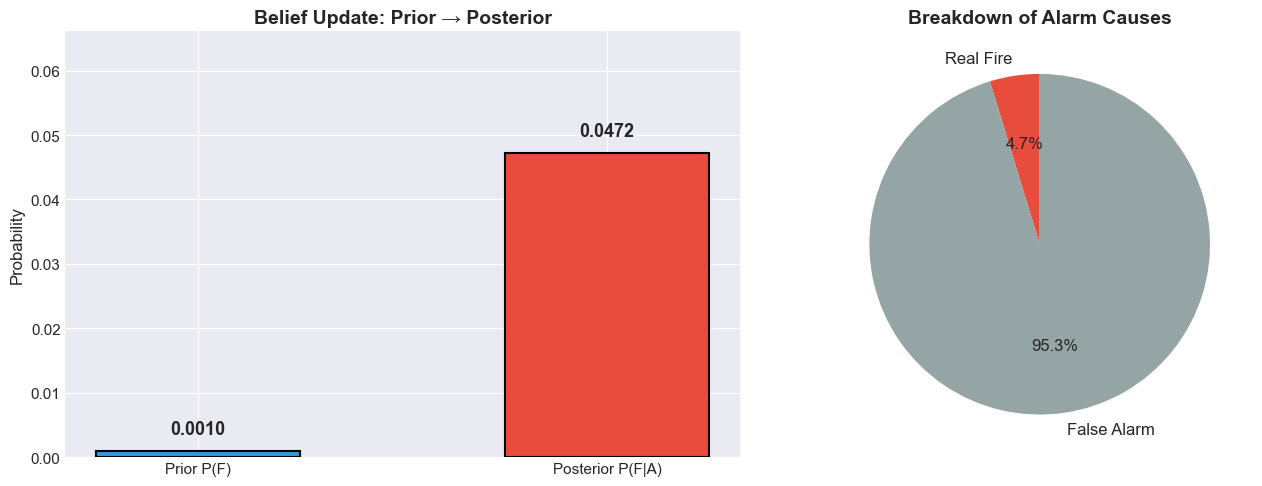


Key Insight: Despite a 99% accurate alarm, the posterior probability of fire
is only 4.7% because fires are rare (prior = 0.001).
Base rates dominate the posterior — this is the lesson of Bayes' rule.


In [60]:
# =============================================================================
# Demonstration: Bayes' Rule for P(F=True | A=True) with Lecture Example Values
# =============================================================================
# We replicate the fire alarm example from Lecture 5A to show how
# the low prior probability dominates the posterior despite a high likelihood.

# Define probabilities from the lecture's fire alarm example (Chen, 2026a)
P_F = 0.001            # Prior: fires are rare (1 in 1000)
P_A_given_F = 0.99     # Likelihood: alarm rings 99% of the time when fire exists
P_A_given_not_F = 0.02 # False alarm rate: alarm rings 2% of the time without fire

# Compute total probability of alarm sounding (law of total probability)
# P(A) = P(A|F)*P(F) + P(A|¬F)*P(¬F)
P_A = P_A_given_F * P_F + P_A_given_not_F * (1 - P_F)  # ≈ 0.02097

# Apply Bayes' rule to get the posterior
# P(F|A) = P(A|F) * P(F) / P(A)
P_F_given_A = (P_A_given_F * P_F) / P_A  # ≈ 0.0472

# Display the step-by-step calculation in a table
bayes_data = {
    'Component': ['Prior P(F)', 'Likelihood P(A|F)', 'False Alarm P(A|¬F)',
                   'Evidence P(A)', 'Posterior P(F|A)'],
    'Value': [f'{P_F:.4f}', f'{P_A_given_F:.4f}', f'{P_A_given_not_F:.4f}',
              f'{P_A:.5f}', f'{P_F_given_A:.4f}'],
    'Interpretation': [
        'Fires are rare — 1 in 1,000 days',
        'Alarm is 99% reliable when fire is present',
        'Alarm falsely rings 2% of the time',
        'Total probability alarm sounds (any cause)',
        'Only ~4.7% chance of real fire given alarm'
    ]
}
df_bayes = pd.DataFrame(bayes_data)
print("Bayes' Rule Calculation: P(F = True | A = True)")
print("=" * 60)
display(df_bayes.style.hide(axis='index').set_properties(**{'text-align': 'left'}))

# Create a visualization comparing prior and posterior
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: bar chart comparing prior vs posterior
categories = ['Prior P(F)', 'Posterior P(F|A)']
values = [P_F, P_F_given_A]
colors = ['#3498db', '#e74c3c']
bars = ax1.bar(categories, values, color=colors, edgecolor='black', linewidth=1.5, width=0.5)
for bar, val in zip(bars, values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.4f}', ha='center', va='bottom', fontsize=13, fontweight='bold')
ax1.set_ylabel('Probability', fontsize=12)
ax1.set_title('Belief Update: Prior → Posterior', fontsize=14, fontweight='bold')
ax1.set_ylim(0, max(values) * 1.4)

# Right panel: pie chart of alarm causes
alarm_fire = P_A_given_F * P_F          # Alarm due to real fire
alarm_no_fire = P_A_given_not_F * (1 - P_F)  # Alarm due to false alarm
ax2.pie([alarm_fire, alarm_no_fire],
        labels=['Real Fire', 'False Alarm'],
        autopct='%1.1f%%', colors=['#e74c3c', '#95a5a6'],
        startangle=90, textprops={'fontsize': 12})
ax2.set_title('Breakdown of Alarm Causes', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nKey Insight: Despite a 99% accurate alarm, the posterior probability of fire")
print(f"is only {P_F_given_A:.1%} because fires are rare (prior = {P_F}).")
print(f"Base rates dominate the posterior — this is the lesson of Bayes' rule.")

### (c) Conditional Independence Relationships

A Bayesian network encodes conditional independence through its graphical structure. A variable is conditionally independent of all its non-descendants given its parents (Russell & Norvig, 2021, Chapter 13). By inspecting the DAG with edges F → S, F → W, F → A, and S → A, we can identify the following two conditional independence relationships.

**Independence 1: S ⊥ W | F (Smoke is conditionally independent of Sprinkler given Fire).**  Smoke and Sprinkler are both children of Fire, but neither is a parent or descendant of the other. Once we know the state of Fire — whether it is occurring or not — learning the sprinkler status provides no additional information about whether smoke is present, and vice versa. This is an example of the "common cause" or "fork" pattern in a Bayesian network. Fire is the common cause of both Smoke and Sprinkler, and conditioning on Fire separates the two child variables. In practical terms, if we already know whether a fire is happening, knowing whether the sprinkler has turned on does not change our expectation about smoke.

**Independence 2: W ⊥ A | F (Sprinkler is conditionally independent of Alarm given Fire).**  In this DAG, Alarm has only two parents: Fire and Smoke — importantly, Sprinkler is **not** a parent of Alarm. Every path from W to A must pass through Fire: the path W ← F → A is a fork at F, and the path W ← F → S → A is a fork at F followed by a chain through S. When Fire is observed (conditioned on), both of these paths are blocked, rendering W and A d-separated given F. Intuitively, once we know whether a fire is occurring, the sprinkler status provides no additional predictive value for the alarm because the alarm depends only on fire and smoke, and smoke is already fully determined by fire in the conditioning set.

A complementary insight involves the "explaining away" effect. Alarm (A) is a collider for Fire (F) and Smoke (S) via the v-structure F → A ← S. If we observe that the alarm sounded (condition on A) but do **not** condition on Fire, learning about smoke changes our belief about fire and vice versa. For instance, if the alarm is ringing but no smoke is detected, our belief that fire is directly responsible increases — this is the explaining-away pattern discussed in the lecture (Chen, 2026a).

| # | Statement | Pattern | Explanation |
|---|-----------|---------|-------------|
| 1 | $S \perp W \mid F$ | Common cause (fork at F) | Knowing Fire separates Smoke and Sprinkler |
| 2 | $W \perp A \mid F$ | Fork at F blocks all W–A paths | Sprinkler adds no info about Alarm once Fire is known |

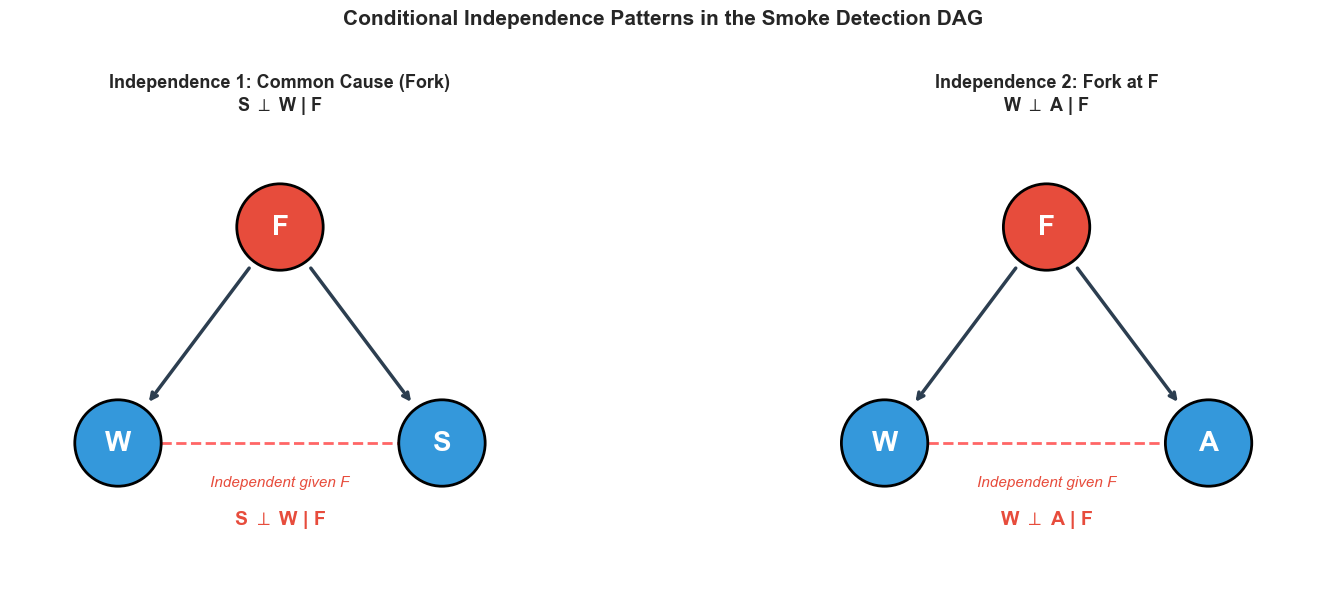

In [61]:
# =============================================================================
# Visualization: Conditional Independence Patterns in the Smoke Detection DAG
# =============================================================================
# This diagram highlights the two conditional independence relationships
# by color-coding the relevant substructures.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Panel 1: Common Cause Pattern (S ⊥ W | F) ---
ax = axes[0]
pos = {'F': (0.5, 0.8), 'S': (0.8, 0.4), 'W': (0.2, 0.4)}
node_colors = {'F': '#e74c3c', 'S': '#3498db', 'W': '#3498db'}  # F red, children blue
for node, (x, y) in pos.items():
    circle = plt.Circle((x, y), 0.08, color=node_colors[node], ec='black', lw=2, zorder=5)
    ax.add_patch(circle)
    ax.text(x, y, node, ha='center', va='center', fontsize=20,
            fontweight='bold', color='white', zorder=6)

# Draw edges F→S and F→W
for tgt in ['S', 'W']:
    x1, y1 = pos['F']
    x2, y2 = pos[tgt]
    dx, dy = x2 - x1, y2 - y1
    ln = np.sqrt(dx**2 + dy**2)
    sh = 0.09
    ax.annotate('', xy=(x2 - sh*dx/ln, y2 - sh*dy/ln),
                xytext=(x1 + sh*dx/ln, y1 + sh*dy/ln),
                arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=2.5))

# Dashed line indicating independence between S and W
ax.plot([0.28, 0.72], [0.4, 0.4], 'r--', lw=2, alpha=0.6)
ax.text(0.5, 0.32, 'Independent given F', ha='center', fontsize=11,
        color='#e74c3c', fontstyle='italic')
ax.text(0.5, 0.25, 'S $\\perp$ W | F', ha='center', fontsize=14, fontweight='bold',
        color='#e74c3c')
ax.set_xlim(0, 1)
ax.set_ylim(0.1, 1.0)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Independence 1: Common Cause (Fork)\nS $\\perp$ W | F',
             fontsize=13, fontweight='bold')

# --- Panel 2: Independence 2 (W ⊥ A | F) ---
ax = axes[1]
pos2 = {'F': (0.5, 0.8), 'W': (0.2, 0.4), 'A': (0.8, 0.4)}
node_colors2 = {'F': '#e74c3c', 'W': '#3498db', 'A': '#3498db'}
for node, (x, y) in pos2.items():
    circle = plt.Circle((x, y), 0.08, color=node_colors2[node], ec='black', lw=2, zorder=5)
    ax.add_patch(circle)
    ax.text(x, y, node, ha='center', va='center', fontsize=20,
            fontweight='bold', color='white', zorder=6)

# Draw edges F→W and F→A (the fork)
for tgt in ['W', 'A']:
    x1, y1 = pos2['F']
    x2, y2 = pos2[tgt]
    dx, dy = x2 - x1, y2 - y1
    ln = np.sqrt(dx**2 + dy**2)
    sh = 0.09
    ax.annotate('', xy=(x2 - sh*dx/ln, y2 - sh*dy/ln),
                xytext=(x1 + sh*dx/ln, y1 + sh*dy/ln),
                arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=2.5))

# Dashed line indicating independence between W and A
ax.plot([0.28, 0.72], [0.4, 0.4], 'r--', lw=2, alpha=0.6)
ax.text(0.5, 0.32, 'Independent given F', ha='center', fontsize=11,
        color='#e74c3c', fontstyle='italic')
ax.text(0.5, 0.25, 'W $\\perp$ A | F', ha='center', fontsize=14, fontweight='bold',
        color='#e74c3c')
ax.set_xlim(0, 1)
ax.set_ylim(0.1, 1.0)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Independence 2: Fork at F\nW $\\perp$ A | F',
             fontsize=13, fontweight='bold')

plt.suptitle('Conditional Independence Patterns in the Smoke Detection DAG',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### (d) Parameter Count: Full Joint vs. Bayesian Network Factorization

When all four variables (F, S, A, W) are binary, we can compare the number of free parameters required under two representations: the full joint distribution and the Bayesian network factorization. The general principle, as stated in the lecture, is that "if we have no structure, a joint over $n$ binary variables requires $2^n - 1$ parameters. But if each node has at most $k$ parents, we only need roughly $n \times 2^k$ parameters" (Chen, 2026a).

**Full joint distribution:** With 4 binary variables, the joint distribution $P(F, S, A, W)$ is a table with $2^4 = 16$ entries. Since probabilities must sum to 1, we need $2^4 - 1 = 15$ free parameters to fully specify the distribution. Every possible combination of the four variables receives its own probability, and these 15 independent values (plus the constraint that they sum to 1) define the entire distribution.

**Bayesian network factorization:** Under the DAG, the joint decomposes into four local factors. $P(F)$ requires 1 free parameter (since $P(F=\text{False}) = 1 - P(F=\text{True})$). $P(S \mid F)$ requires 2 free parameters (one for each value of F). $P(W \mid F)$ also requires 2 free parameters. $P(A \mid F, S)$ has two parents, so it requires $2^2 = 4$ free parameters (one for each of the 4 parent configurations). The total is $1 + 2 + 2 + 4 = 9$ free parameters.

**Computational implication:** The savings here are noticeable (15 vs. 9, a 40% reduction) because the alarm depends on only two parents rather than all three other variables. The advantage grows dramatically with network size. For a network with $n$ binary variables and at most $k$ parents per node, the full joint requires $2^n - 1$ parameters (exponential in $n$), while the Bayesian network factorization requires at most $n \cdot 2^k$ parameters (linear in $n$ when $k$ is bounded). For a 50-variable network with at most 3 parents per node, the full joint would need over $10^{15}$ parameters, whereas the Bayesian network would need only about $50 \times 8 = 400$ parameters — a savings of over twelve orders of magnitude. This factorization is what makes Bayesian networks computationally tractable for real-world applications (Russell & Norvig, 2021).

Parameter Count Comparison (4 Binary Variables)


Representation,Free Parameters,Growth Pattern
"Full Joint P(F,S,A,W)",15,2^4 - 1 = 15
Bayesian Network Factorization,9,1 + 2 + 2 + 4 = 9



Bayesian Network Breakdown:
  P(F)            → 1 free parameter(s)
  P(S|F)          → 2 free parameter(s)
  P(W|F)          → 2 free parameter(s)
  P(A|F,S)        → 4 free parameter(s)
  Total           → 9


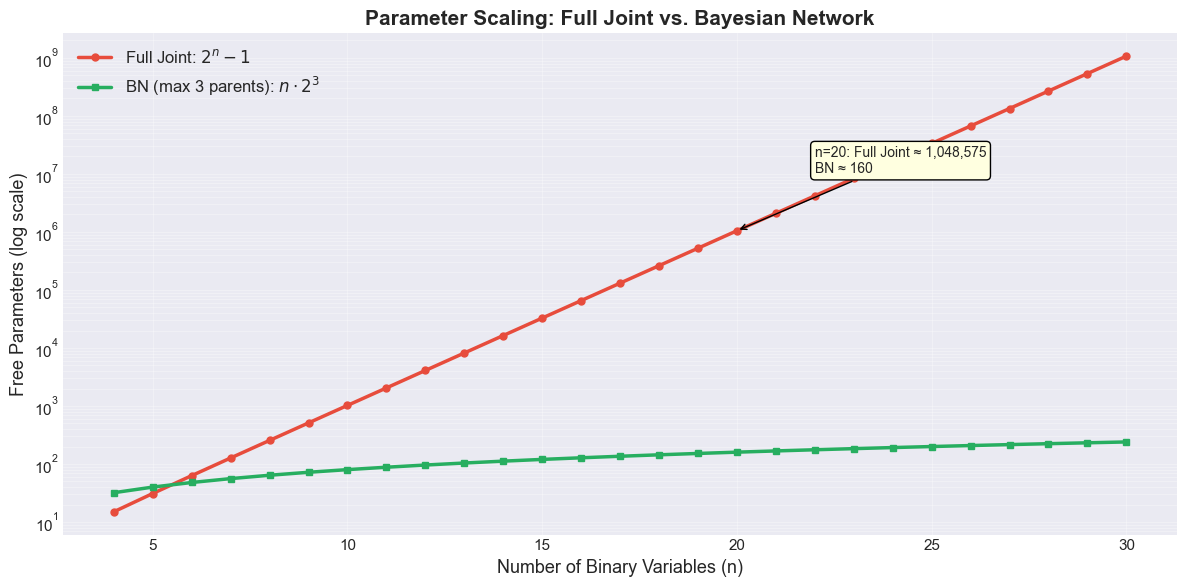


At n=20 variables: Full joint needs 1,048,575 params vs BN needs 160 params.
That is a 6,554x reduction — this is why BN factorization matters.


In [62]:
# =============================================================================
# Computation and Visualization: Parameter Count Comparison
# =============================================================================
# Compare the number of free parameters needed for the full joint distribution
# versus the Bayesian network factorization.

# --- Part 1: This specific 4-variable network ---
n_vars = 4  # Number of binary variables

# Full joint: 2^n - 1 free parameters
full_joint_params = 2**n_vars - 1  # 15

# Bayesian network factorization:
# P(F): 1 param, P(S|F): 2 params, P(W|F): 2 params, P(A|F,S): 4 params
bn_params = {'P(F)': 1, 'P(S|F)': 2, 'P(W|F)': 2, 'P(A|F,S)': 4}
bn_total = sum(bn_params.values())  # 9

param_table = {
    'Representation': ['Full Joint P(F,S,A,W)', 'Bayesian Network Factorization'],
    'Free Parameters': [full_joint_params, bn_total],
    'Growth Pattern': [f'2^{n_vars} - 1 = {full_joint_params}',
                       ' + '.join(f'{v}' for v in bn_params.values()) + f' = {bn_total}']
}
print("Parameter Count Comparison (4 Binary Variables)")
print("=" * 55)
display(pd.DataFrame(param_table).style.hide(axis='index').set_properties(**{'text-align': 'left'}))

# Print BN breakdown
print(f"\nBayesian Network Breakdown:")
for factor, count in bn_params.items():
    print(f"  {factor:15s} → {count} free parameter(s)")
print(f"  {'Total':15s} → {bn_total}")

# --- Part 2: Scaling comparison as n grows ---
fig, ax = plt.subplots(figsize=(12, 6))

n_range = np.arange(4, 31)           # Network sizes from 4 to 30 variables
full_joint = 2.0**n_range - 1        # Exponential growth for full joint
k_max = 3                            # Assume at most 3 parents per node
bn_factored = n_range * 2**k_max     # Linear growth for BN factorization

ax.semilogy(n_range, full_joint, 'o-', color='#e74c3c', lw=2.5,
            markersize=5, label=f'Full Joint: $2^n - 1$')
ax.semilogy(n_range, bn_factored, 's-', color='#27ae60', lw=2.5,
            markersize=5, label=f'BN (max {k_max} parents): $n \\cdot 2^{k_max}$')

ax.set_xlabel('Number of Binary Variables (n)', fontsize=13)
ax.set_ylabel('Free Parameters (log scale)', fontsize=13)
ax.set_title('Parameter Scaling: Full Joint vs. Bayesian Network',
             fontsize=15, fontweight='bold')
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, which='both', alpha=0.3)

# Add annotation showing the gap at n=20
n20_fj = 2**20 - 1
n20_bn = 20 * 2**k_max
ax.annotate(f'n=20: Full Joint ≈ {n20_fj:,.0f}\nBN ≈ {n20_bn}',
            xy=(20, n20_fj), xytext=(22, n20_fj * 10),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='black'),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow'))

plt.tight_layout()
plt.show()

print(f"\nAt n=20 variables: Full joint needs {n20_fj:,} params vs BN needs {n20_bn} params.")
print(f"That is a {n20_fj / n20_bn:,.0f}x reduction — this is why BN factorization matters.")

### (e) Probabilistic Modeling vs. Deterministic Rule-Based Logic

Probabilistic modeling is fundamentally different from deterministic rule-based logic in this scenario because the relationship between fire, smoke, alarms, and sprinklers is inherently uncertain — not every fire produces visible smoke, alarms can be triggered falsely, and sprinklers occasionally activate due to mechanical faults. A deterministic rule such as "IF alarm = ON THEN fire = TRUE" cannot capture this nuance; it forces a binary conclusion that fails whenever the alarm is a false positive. In contrast, a probabilistic model assigns degrees of belief to each possible state of the world and updates those beliefs rationally as evidence arrives, using Bayes' rule (Chen, 2026a). As the lecture emphasizes, "real-world AI rarely operates in binary certainty" and "instead of trying to deduce truth deterministically, we model degrees of belief" (Chen, 2026a). The probabilistic approach also quantifies the relationships between variables through conditional probability tables, allowing the system to reason about the likelihood of multiple causes simultaneously — for instance, distinguishing whether an alarm was caused by fire, steam from cooking, or a sensor malfunction — rather than committing to a single deterministic explanation.

---
## Question 2: VE vs. JT — Variable Elimination and Junction Tree (Lecture 5B)

We are given the classic Sprinkler Bayesian network with four binary variables: **C** (Cloudy), **R** (Rain), **S** (Sprinkler), and **W** (Wet Grass). The DAG shows C → R, C → S, R → W, and S → W. The query of interest is **P(R | W = true)**: given that the grass is wet, what is the probability that it rained?

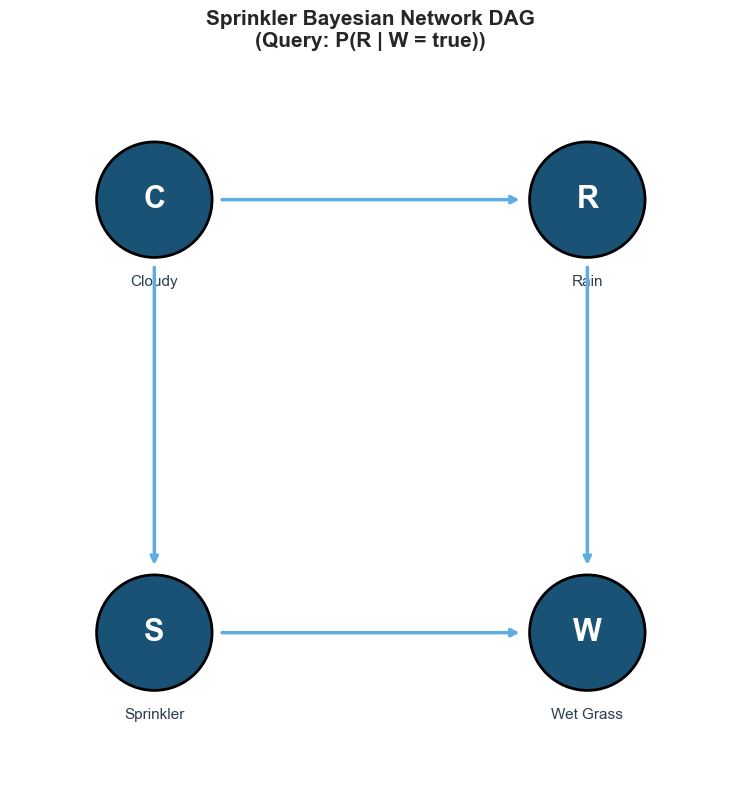

In [63]:
# =============================================================================
# Visualization: Sprinkler Bayesian Network DAG (Picture2)
# =============================================================================
fig, ax = plt.subplots(figsize=(8, 8))

positions = {
    'C': (0.2, 0.8),  # Cloudy top-left
    'R': (0.8, 0.8),  # Rain top-right
    'S': (0.2, 0.2),  # Sprinkler bottom-left
    'W': (0.8, 0.2),  # Wet Grass bottom-right
}
full_names = {'C': 'Cloudy', 'R': 'Rain', 'S': 'Sprinkler', 'W': 'Wet Grass'}

for node, (x, y) in positions.items():
    circle = plt.Circle((x, y), 0.08, color='#1A5276', ec='black', lw=2, zorder=5)
    ax.add_patch(circle)
    ax.text(x, y, node, ha='center', va='center', fontsize=22,
            fontweight='bold', color='white', zorder=6)
    ax.text(x, y - 0.12, full_names[node], ha='center', fontsize=11, color='#2C3E50')

edges = [('C', 'R'), ('C', 'S'), ('R', 'W'), ('S', 'W')]
for src, tgt in edges:
    x1, y1 = positions[src]
    x2, y2 = positions[tgt]
    dx, dy = x2 - x1, y2 - y1
    ln = np.sqrt(dx**2 + dy**2)
    sh = 0.09
    ax.annotate('', xy=(x2 - sh*dx/ln, y2 - sh*dy/ln),
                xytext=(x1 + sh*dx/ln, y1 + sh*dy/ln),
                arrowprops=dict(arrowstyle='->', color='#5DADE2', lw=2.5))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Sprinkler Bayesian Network DAG\n(Query: P(R | W = true))',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.1 How Each Algorithm Computes the Posterior

**Variable Elimination (VE)** computes the posterior $P(R \mid W = \text{true})$ by converting all conditional probability tables (CPTs) into factors, restricting factors to the observed evidence ($W = \text{true}$), and then systematically eliminating hidden variables (C and S) one at a time according to a chosen elimination order. For each hidden variable, VE collects all factors that mention that variable, multiplies them together into a single product factor, and then sums out (marginalizes) the variable from the product. The result of this sum-out operation is a new, smaller factor that no longer depends on the eliminated variable. After all hidden variables have been eliminated, the remaining factors involve only the query variable R. VE multiplies these remaining factors and normalizes the result so the probabilities sum to 1, yielding the exact posterior. This process is a form of dynamic programming: by interleaving multiplication and summation, VE avoids constructing the full joint distribution, instead passing intermediate results forward as compact factors (Chen, 2026b).

**Junction Tree (JT)** takes a different organizational approach. It first transforms the Bayesian network into a junction tree — a tree of cliques where each clique is a maximal fully connected subset of variables in the moralized, triangulated graph. The evidence is incorporated by assigning it to the appropriate cliques. Calibration then proceeds in two passes: an inward (collection) pass where messages flow from leaf cliques toward a chosen root, and an outward (distribution) pass where accumulated information flows back to all cliques. Each message is computed by multiplying a clique's local potential with all incoming messages (except from the recipient), then marginalizing out variables not shared with the neighboring clique. After calibration, every clique holds a consistent belief over its variables, and any marginal query can be answered by finding the clique that contains the query variable and marginalizing its calibrated belief (Chen, 2026b).

### 2.2 Where Summation Occurs

In **Variable Elimination**, summation occurs in the `sum_out(product, var)` step inside the elimination loop. After all factors containing a hidden variable have been multiplied together, the product factor is summed over all values of that variable, producing a factor with one fewer dimension. This is the marginalization operation: $\tau(Z_{\text{remaining}}) = \sum_{z} \text{product}(z, Z_{\text{remaining}})$.

In **Junction Tree**, summation occurs inside the `calibrate(JT)` step, specifically during message computation. When a clique sends a message to a neighboring clique, it marginalizes its combined belief (local potential times incoming messages) over the variables not in the separator — that is, it sums out the variables that are private to the sending clique. This happens in both the inward and outward passes.

### 2.3 Where Multiplication Occurs

In **Variable Elimination**, multiplication occurs in two places. First, the `multiply(related)` step inside the loop multiplies all factors that share the variable being eliminated into a single product factor. Second, after all hidden variables are eliminated, `multiply(factors)` combines any remaining factors before normalization.

In **Junction Tree**, multiplication also occurs during calibration. When computing a message, a clique multiplies its local potential (the CPT assigned to it) by all incoming messages from other neighbors. Additionally, after both passes complete, each clique's final belief is the product of its local potential and all incoming messages from every neighbor.

### 2.4 Why VE Must Be Repeated but JT Does Not

Variable Elimination is a **query-driven** algorithm. The elimination order is chosen to efficiently answer **one specific query**, and the intermediate factors produced during elimination are tailored to that particular query variable. If we change the query from $P(R \mid W = \text{true})$ to $P(C \mid W = \text{true})$, the elimination order changes (because now R might be eliminated instead of retained), and all intermediate factors must be recomputed from scratch. The algorithm discards intermediate results once the query is answered.

Junction Tree is a **model-driven** algorithm. The upfront investment of building the tree structure and performing full calibration ensures that **every clique** in the tree holds a globally consistent belief. Once calibration is complete, answering a new query only requires identifying the clique that contains the new query variable and marginalizing its belief — a trivially cheap operation compared to re-running the entire algorithm. The calibrated junction tree effectively precomputes the answers to all possible single-variable marginal queries simultaneously, amortizing the cost of inference across many queries (Chen, 2026b).

### 2.5 Computational Trade-offs

| Aspect | Variable Elimination | Junction Tree |
|--------|---------------------|---------------|
| Setup cost | Minimal (just list factors) | High (moralize, triangulate, build tree) |
| Per-query cost | Full elimination each time | Cheap lookup after calibration |
| Best for few queries | Efficient — no wasted computation | Overhead of tree construction is wasteful |
| Best for many queries | Redundant work each time | Amortized cost pays off |
| Space complexity | Intermediate factors discarded | Full tree stored in memory |
| Time complexity | $O(n \cdot k^{w+1})$ per query | $O(n \cdot k^{w+1})$ once; $O(k^{c})$ per query |

Both algorithms share the same worst-case exponential dependency on treewidth $w$, so neither escapes the fundamental hardness of inference in densely connected networks. The choice between them is a trade-off between setup cost and amortized per-query cost.

### 2.6 Scenarios Where Each Is Preferable

**VE is preferable** in a scenario where we have a large Bayesian network but need to answer only a single query — for example, a one-time diagnostic question such as "What is the probability of engine failure given these specific sensor readings?" In this case, VE avoids the overhead of constructing and storing the entire junction tree, which would be wasted if we never ask another question.

**JT is preferable** in a real-time monitoring system such as an industrial plant or a hospital ICU, where the Bayesian network models dozens of interacting variables and the system must continuously answer many different queries as new evidence streams in — for example, "What is the probability of equipment X failing?", "What is the probability of condition Y?", etc. Building the junction tree once and updating it as evidence changes is far more efficient than running VE from scratch for every new query (Chen, 2026b).

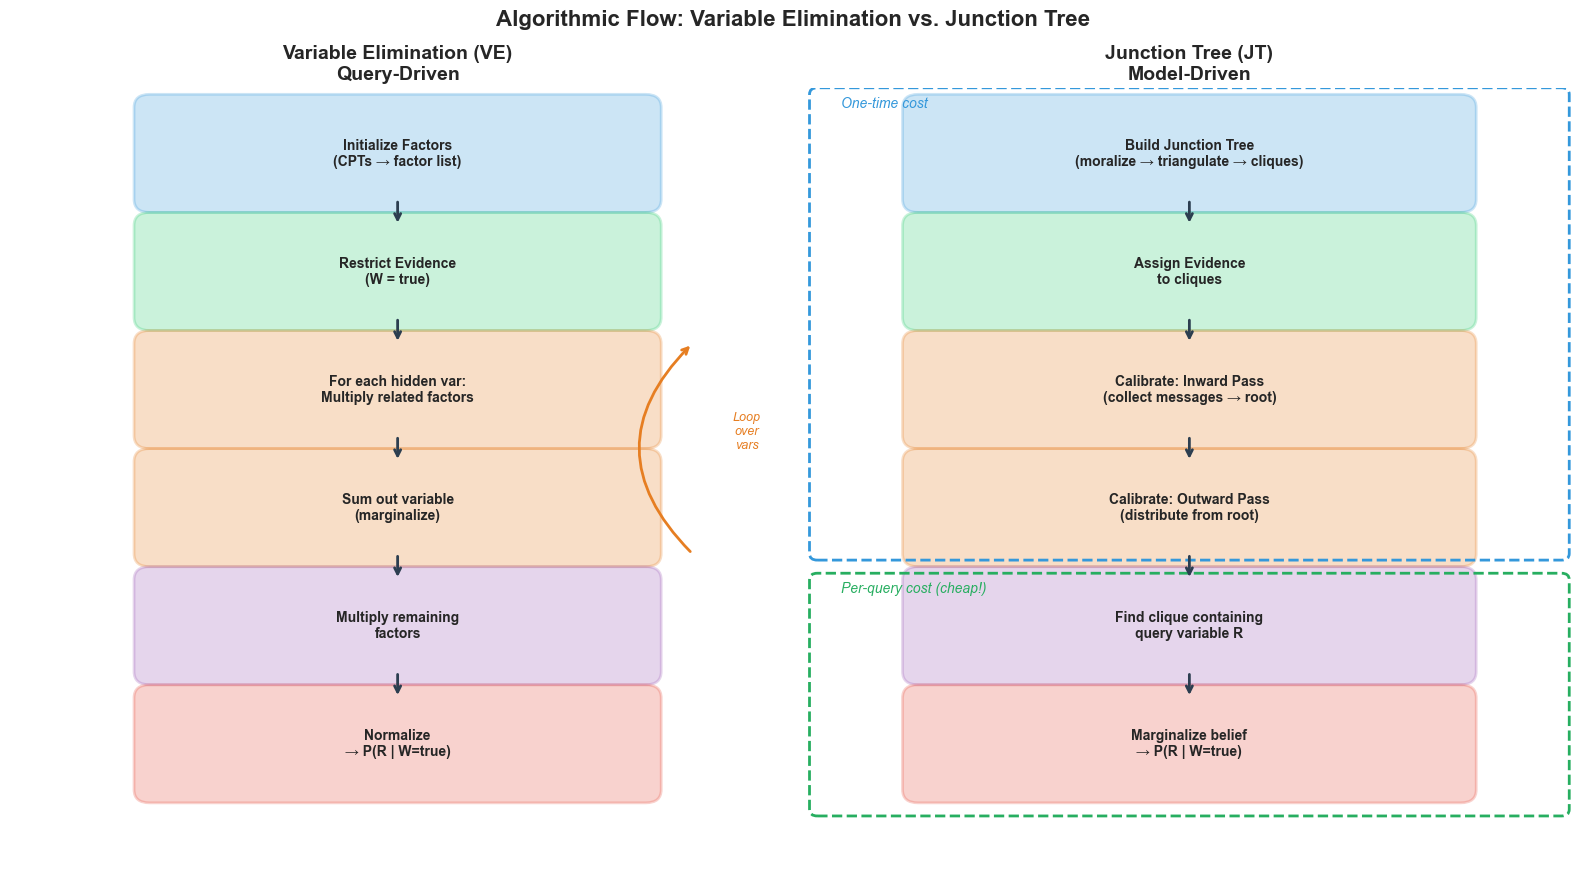

In [64]:
# =============================================================================
# Visualization: VE vs JT Algorithmic Flow Comparison
# =============================================================================
# This chart provides a side-by-side comparison of the two algorithms' workflows
# and computational characteristics.

fig, axes = plt.subplots(1, 2, figsize=(16, 9))

# --- Panel 1: VE Algorithm Flow ---
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 12)
ax.axis('off')
ax.set_title('Variable Elimination (VE)\nQuery-Driven', fontsize=14, fontweight='bold')

ve_steps = [
    (5, 11.0, 'Initialize Factors\n(CPTs → factor list)', '#3498db'),
    (5, 9.2,  'Restrict Evidence\n(W = true)', '#2ecc71'),
    (5, 7.4,  'For each hidden var:\nMultiply related factors', '#e67e22'),
    (5, 5.6,  'Sum out variable\n(marginalize)', '#e67e22'),
    (5, 3.8,  'Multiply remaining\nfactors', '#9b59b6'),
    (5, 2.0,  'Normalize\n→ P(R | W=true)', '#e74c3c'),
]

for i, (x, y, text, color) in enumerate(ve_steps):
    box = mpatches.FancyBboxPatch((x - 3.2, y - 0.7), 6.4, 1.4,
                                   boxstyle='round,pad=0.2',
                                   facecolor=color, alpha=0.25,
                                   edgecolor=color, lw=2)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=10, fontweight='bold')
    if i < len(ve_steps) - 1:
        ax.annotate('', xy=(5, ve_steps[i+1][1] + 0.7),
                    xytext=(5, y - 0.7),
                    arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=2))

# Loop indicator for elimination steps
ax.annotate('', xy=(8.8, 7.4 + 0.7), xytext=(8.8, 5.6 - 0.7),
            arrowprops=dict(arrowstyle='->', color='#e67e22', lw=2,
                           connectionstyle='arc3,rad=-0.5'))
ax.text(9.5, 6.5, 'Loop\nover\nvars', ha='center', fontsize=9,
        color='#e67e22', fontstyle='italic')

# --- Panel 2: JT Algorithm Flow ---
ax = axes[1]
ax.set_xlim(0, 10)
ax.set_ylim(0, 12)
ax.axis('off')
ax.set_title('Junction Tree (JT)\nModel-Driven', fontsize=14, fontweight='bold')

jt_steps = [
    (5, 11.0, 'Build Junction Tree\n(moralize → triangulate → cliques)', '#3498db'),
    (5, 9.2,  'Assign Evidence\nto cliques', '#2ecc71'),
    (5, 7.4,  'Calibrate: Inward Pass\n(collect messages → root)', '#e67e22'),
    (5, 5.6,  'Calibrate: Outward Pass\n(distribute from root)', '#e67e22'),
    (5, 3.8,  'Find clique containing\nquery variable R', '#9b59b6'),
    (5, 2.0,  'Marginalize belief\n→ P(R | W=true)', '#e74c3c'),
]

for i, (x, y, text, color) in enumerate(jt_steps):
    box = mpatches.FancyBboxPatch((x - 3.5, y - 0.7), 7.0, 1.4,
                                   boxstyle='round,pad=0.2',
                                   facecolor=color, alpha=0.25,
                                   edgecolor=color, lw=2)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=10, fontweight='bold')
    if i < len(jt_steps) - 1:
        ax.annotate('', xy=(5, jt_steps[i+1][1] + 0.7),
                    xytext=(5, y - 0.7),
                    arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=2))

# Mark "one-time cost" vs "per-query cost"
ax.add_patch(mpatches.FancyBboxPatch((0.2, 4.9), 9.6, 7.0,
             boxstyle='round,pad=0.1', facecolor='none',
             edgecolor='#3498db', lw=2, ls='--'))
ax.text(0.5, 11.7, 'One-time cost', fontsize=10, color='#3498db', fontstyle='italic')

ax.add_patch(mpatches.FancyBboxPatch((0.2, 1.0), 9.6, 3.5,
             boxstyle='round,pad=0.1', facecolor='none',
             edgecolor='#27ae60', lw=2, ls='--'))
ax.text(0.5, 4.3, 'Per-query cost (cheap!)', fontsize=10,
        color='#27ae60', fontstyle='italic')

plt.suptitle('Algorithmic Flow: Variable Elimination vs. Junction Tree',
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

In [65]:
# =============================================================================
# Table: Detailed Operation Mapping for VE and JT
# =============================================================================
# Summarize where each core operation (multiplication, summation) appears
# in the two algorithms' pseudocode.

operations_data = {
    'Operation': [
        'Factor Multiplication',
        'Factor Multiplication',
        'Summation (Marginalization)',
        'Summation (Marginalization)',
        'Normalization',
        'Normalization'
    ],
    'Algorithm': ['VE', 'JT', 'VE', 'JT', 'VE', 'JT'],
    'Location in Pseudocode': [
        'multiply(related) inside elimination loop',
        'Clique potential × incoming messages during calibrate()',
        'sum_out(product, var) inside elimination loop',
        'Marginalize over non-separator vars when sending messages',
        'normalize(multiply(factors)) at the end',
        'marginalize(clique.belief, query) returns normalized result'
    ],
    'When It Happens': [
        'Once per hidden variable per query',
        'Once per clique edge during calibration (both passes)',
        'Once per hidden variable per query',
        'Once per message during calibration',
        'Once at the end of each query',
        'Once per query (cheap lookup)'
    ]
}
df_ops = pd.DataFrame(operations_data)
print("Operation Mapping: VE vs. JT")
print("=" * 55)
display(df_ops.style.hide(axis='index').set_properties(**{'text-align': 'left', 'white-space': 'normal', 'max-width': '300px'}))

Operation Mapping: VE vs. JT


Operation,Algorithm,Location in Pseudocode,When It Happens
Factor Multiplication,VE,multiply(related) inside elimination loop,Once per hidden variable per query
Factor Multiplication,JT,Clique potential × incoming messages during calibrate(),Once per clique edge during calibration (both passes)
Summation (Marginalization),VE,"sum_out(product, var) inside elimination loop",Once per hidden variable per query
Summation (Marginalization),JT,Marginalize over non-separator vars when sending messages,Once per message during calibration
Normalization,VE,normalize(multiply(factors)) at the end,Once at the end of each query
Normalization,JT,"marginalize(clique.belief, query) returns normalized result",Once per query (cheap lookup)


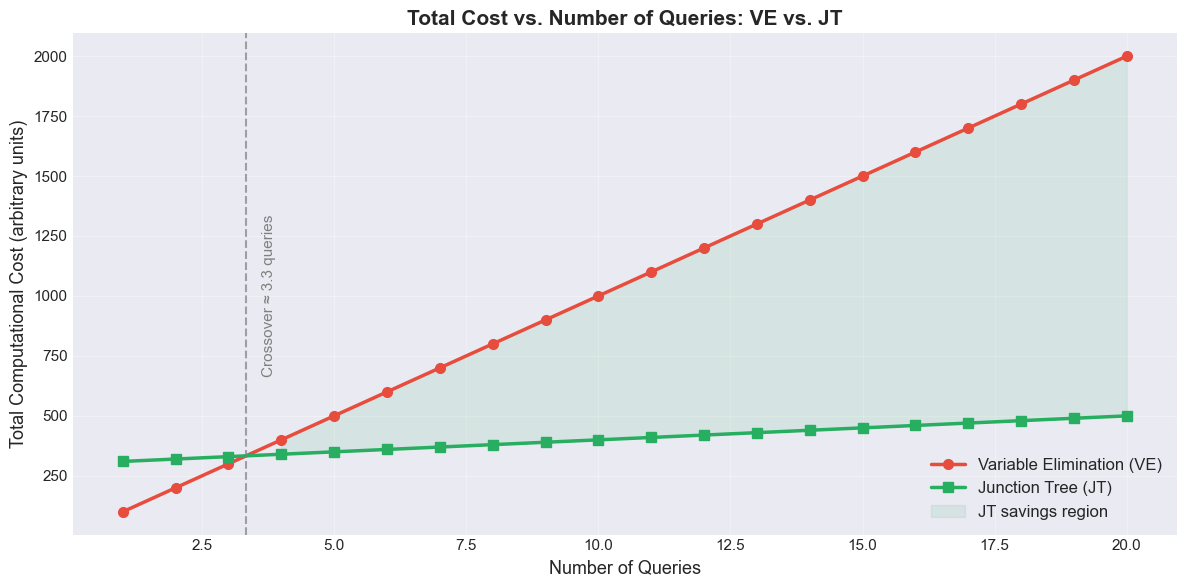

Crossover point: JT becomes cheaper after ~3 queries.
For single queries, VE avoids JT's setup overhead.
For repeated queries, JT's one-time calibration cost is amortized.


In [66]:
# =============================================================================
# Visualization: Query Cost Comparison — VE (repeated) vs JT (amortized)
# =============================================================================
# This plot shows how total computational cost grows as the number of queries
# increases, illustrating the amortization advantage of JT.

num_queries = np.arange(1, 21)             # 1 to 20 queries
ve_cost_per_query = 100                     # Arbitrary unit cost for one VE run
jt_setup_cost = 300                         # Junction tree construction + calibration
jt_query_cost = 10                          # Cost per query after calibration

ve_total = ve_cost_per_query * num_queries  # Linear: repeat full cost each time
jt_total = jt_setup_cost + jt_query_cost * num_queries  # High start, slow growth

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(num_queries, ve_total, 'o-', color='#e74c3c', lw=2.5, markersize=7,
        label='Variable Elimination (VE)')
ax.plot(num_queries, jt_total, 's-', color='#27ae60', lw=2.5, markersize=7,
        label='Junction Tree (JT)')

# Find crossover point
crossover = jt_setup_cost / (ve_cost_per_query - jt_query_cost)
ax.axvline(x=crossover, color='gray', ls='--', lw=1.5, alpha=0.7)
ax.text(crossover + 0.3, max(ve_total) * 0.5,
        f'Crossover ≈ {crossover:.1f} queries', fontsize=11,
        color='gray', rotation=90, va='center')

ax.fill_between(num_queries, ve_total, jt_total,
                where=(num_queries > crossover),
                alpha=0.1, color='#27ae60', label='JT savings region')

ax.set_xlabel('Number of Queries', fontsize=13)
ax.set_ylabel('Total Computational Cost (arbitrary units)', fontsize=13)
ax.set_title('Total Cost vs. Number of Queries: VE vs. JT', fontsize=15, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Crossover point: JT becomes cheaper after ~{crossover:.0f} queries.")
print("For single queries, VE avoids JT's setup overhead.")
print("For repeated queries, JT's one-time calibration cost is amortized.")

---
## Question 3: Estimating a Posterior by Sampling (Lecture 5C)

We consider a small Bayesian network with three binary variables: **Disease (D)**, **Test (T)**, and **Symptom (S)**. The structure is D → T and D → S, meaning Test and Symptom are conditionally independent given Disease. The goal is to estimate $P(D = \text{true} \mid T = \text{positive}, S = \text{true})$ using rejection sampling rather than exact inference.

### Given Probabilities

| Parameter | Value | Meaning |
|-----------|-------|---------|
| $P(D = \text{true})$ | 0.05 | Disease prevalence is 5% |
| $P(T = \text{pos} \mid D = \text{true})$ | 0.90 | Test has 90% sensitivity |
| $P(T = \text{pos} \mid D = \text{false})$ | 0.10 | Test has 10% false positive rate |
| $P(S = \text{true} \mid D = \text{true})$ | 0.80 | 80% of diseased show symptoms |
| $P(S = \text{true} \mid D = \text{false})$ | 0.20 | 20% of healthy show symptoms |

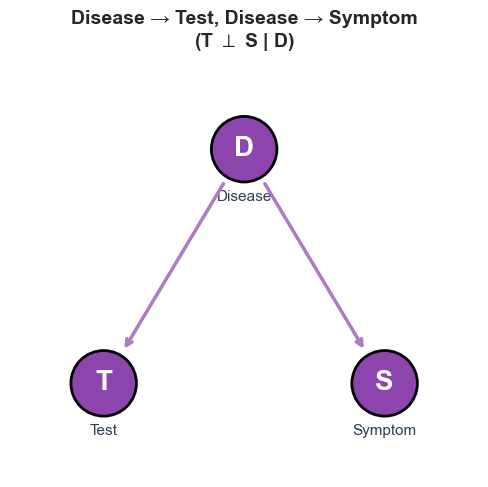

In [67]:
# =============================================================================
# Visualization: Disease-Test-Symptom Bayesian Network DAG
# =============================================================================
fig, ax = plt.subplots(figsize=(8, 5))

pos_dag = {'D': (0.5, 0.8), 'T': (0.2, 0.3), 'S': (0.8, 0.3)}
full = {'D': 'Disease', 'T': 'Test', 'S': 'Symptom'}

for node, (x, y) in pos_dag.items():
    circle = plt.Circle((x, y), 0.07, color='#8E44AD', ec='black', lw=2, zorder=5)
    ax.add_patch(circle)
    ax.text(x, y, node, ha='center', va='center', fontsize=20,
            fontweight='bold', color='white', zorder=6)
    ax.text(x, y - 0.11, full[node], ha='center', fontsize=11, color='#2C3E50')

for tgt in ['T', 'S']:
    x1, y1 = pos_dag['D']
    x2, y2 = pos_dag[tgt]
    dx, dy = x2 - x1, y2 - y1
    ln = np.sqrt(dx**2 + dy**2)
    sh = 0.08
    ax.annotate('', xy=(x2 - sh*dx/ln, y2 - sh*dy/ln),
                xytext=(x1 + sh*dx/ln, y1 + sh*dy/ln),
                arrowprops=dict(arrowstyle='->', color='#AF7AC5', lw=2.5))

ax.set_xlim(0, 1)
ax.set_ylim(0.1, 1.0)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Disease → Test, Disease → Symptom\n(T $\\perp$ S | D)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [68]:
# =============================================================================
# Exact Solution via Variable Elimination (for comparison)
# =============================================================================
# Before running the sampling simulation, we compute the exact posterior
# analytically so we have a ground truth to compare against.

# Given conditional probability tables
P_D_true = 0.05             # Prior probability of disease
P_D_false = 1 - P_D_true    # 0.95

P_T_pos_given_D_true = 0.90   # Sensitivity (true positive rate)
P_T_pos_given_D_false = 0.10  # False positive rate

P_S_true_given_D_true = 0.80  # Symptom rate when diseased
P_S_true_given_D_false = 0.20 # Symptom rate when healthy

# Compute joint P(D, T=pos, S=true) for each value of D using BN factorization:
# P(D, T=pos, S=true) = P(D) * P(T=pos|D) * P(S=true|D)

# Case 1: D = true
joint_D_true = P_D_true * P_T_pos_given_D_true * P_S_true_given_D_true
# = 0.05 * 0.90 * 0.80 = 0.036

# Case 2: D = false
joint_D_false = P_D_false * P_T_pos_given_D_false * P_S_true_given_D_false
# = 0.95 * 0.10 * 0.20 = 0.019

# Evidence probability: P(T=pos, S=true) = sum over D
P_evidence = joint_D_true + joint_D_false  # 0.036 + 0.019 = 0.055

# Exact posterior via Bayes' rule
exact_posterior = joint_D_true / P_evidence  # 0.036 / 0.055 ≈ 0.6545

print("Exact Posterior Computation via Variable Elimination")
print("=" * 60)
print(f"P(D=T, T=pos, S=T)  = {P_D_true} × {P_T_pos_given_D_true} × {P_S_true_given_D_true}")
print(f"                     = {joint_D_true:.4f}")
print(f"P(D=F, T=pos, S=T)  = {P_D_false} × {P_T_pos_given_D_false} × {P_S_true_given_D_false}")
print(f"                     = {joint_D_false:.4f}")
print(f"P(T=pos, S=T)       = {joint_D_true:.4f} + {joint_D_false:.4f} = {P_evidence:.4f}")
print(f"\nExact Posterior:")
print(f"P(D=true | T=pos, S=true) = {joint_D_true:.4f} / {P_evidence:.4f} = {exact_posterior:.6f}")
print(f"                          ≈ {exact_posterior:.2%}")

Exact Posterior Computation via Variable Elimination
P(D=T, T=pos, S=T)  = 0.05 × 0.9 × 0.8
                     = 0.0360
P(D=F, T=pos, S=T)  = 0.95 × 0.1 × 0.2
                     = 0.0190
P(T=pos, S=T)       = 0.0360 + 0.0190 = 0.0550

Exact Posterior:
P(D=true | T=pos, S=true) = 0.0360 / 0.0550 = 0.654545
                          ≈ 65.45%


In [69]:
# =============================================================================
# Rejection Sampling Implementation
# =============================================================================
# This function implements rejection sampling for the Disease-Test-Symptom
# Bayesian network. Each line is commented to explain its purpose.

def rejection_sampling(n_samples, seed=42):
    """
    Estimate P(D=true | T=positive, S=true) using rejection sampling.
    
    Algorithm:
        1. Sample Disease from its prior P(D).
        2. Sample Test conditioned on Disease: P(T | D).
        3. Sample Symptom conditioned on Disease: P(S | D).
        4. Keep only samples matching evidence: T=positive AND S=true.
        5. Estimate posterior as fraction of kept samples where D=true.
    
    Parameters:
        n_samples (int): Total number of forward samples to generate.
        seed (int): Random seed for reproducibility.
    
    Returns:
        estimate (float): Estimated posterior probability (NaN if no samples kept).
        n_kept (int): Number of samples matching evidence.
        n_kept_D_true (int): Number of kept samples where D=true.
        kept_D_values (list): Disease values of all kept samples.
    """
    rng = np.random.default_rng(seed)  # Create a reproducible random generator
    
    n_kept = 0          # Counter for samples that match the evidence
    n_kept_D_true = 0   # Counter for kept samples where Disease = true
    kept_D_values = []   # Store D values of kept samples for analysis
    
    for _ in range(n_samples):
        # Step 1: Sample Disease from prior P(D=true) = 0.05
        D = rng.random() < P_D_true                         # True with probability 0.05
        
        # Step 2: Sample Test conditioned on Disease
        if D:
            T = rng.random() < P_T_pos_given_D_true         # P(T=pos|D=T) = 0.90
        else:
            T = rng.random() < P_T_pos_given_D_false         # P(T=pos|D=F) = 0.10
        
        # Step 3: Sample Symptom conditioned on Disease
        if D:
            S = rng.random() < P_S_true_given_D_true         # P(S=T|D=T) = 0.80
        else:
            S = rng.random() < P_S_true_given_D_false         # P(S=T|D=F) = 0.20
        
        # Step 4: Rejection — keep only if evidence matches (T=pos AND S=true)
        if T and S:
            n_kept += 1                 # This sample passes the evidence filter
            kept_D_values.append(D)     # Record Disease state of this kept sample
            if D:
                n_kept_D_true += 1      # Count kept samples where D=true
    
    # Step 5: Estimate posterior
    if n_kept == 0:
        estimate = float('nan')         # Cannot estimate if no samples match evidence
    else:
        estimate = n_kept_D_true / n_kept  # Fraction of kept samples with D=true
    
    return estimate, n_kept, n_kept_D_true, kept_D_values

# =============================================================================
# Run simulation at three sample sizes: 100, 1000, 10000
# =============================================================================
sample_sizes = [100, 1_000, 10_000]
results = []

print("Rejection Sampling Results")
print("=" * 75)
print(f"{'N Samples':>12} {'Kept':>8} {'D=true':>8} {'Estimate':>12} {'Exact':>12} {'Error':>10}")
print("-" * 75)

for n in sample_sizes:
    est, kept, d_true, _ = rejection_sampling(n, seed=42)
    error = abs(est - exact_posterior) if not np.isnan(est) else float('nan')
    results.append({'n_samples': n, 'estimate': est, 'kept': kept,
                    'd_true': d_true, 'error': error})
    print(f"{n:>12,} {kept:>8} {d_true:>8} {est:>12.6f} {exact_posterior:>12.6f} {error:>10.6f}")

print("-" * 75)
print(f"\nExact posterior: P(D=true | T=pos, S=true) = {exact_posterior:.6f}")
print(f"Acceptance rate ≈ P(T=pos, S=true) = {P_evidence:.4f} = {P_evidence:.1%}")

Rejection Sampling Results
   N Samples     Kept   D=true     Estimate        Exact      Error
---------------------------------------------------------------------------
         100        7        4     0.571429     0.654545   0.083117
       1,000       55       34     0.618182     0.654545   0.036364
      10,000      578      374     0.647059     0.654545   0.007487
---------------------------------------------------------------------------

Exact posterior: P(D=true | T=pos, S=true) = 0.654545
Acceptance rate ≈ P(T=pos, S=true) = 0.0550 = 5.5%


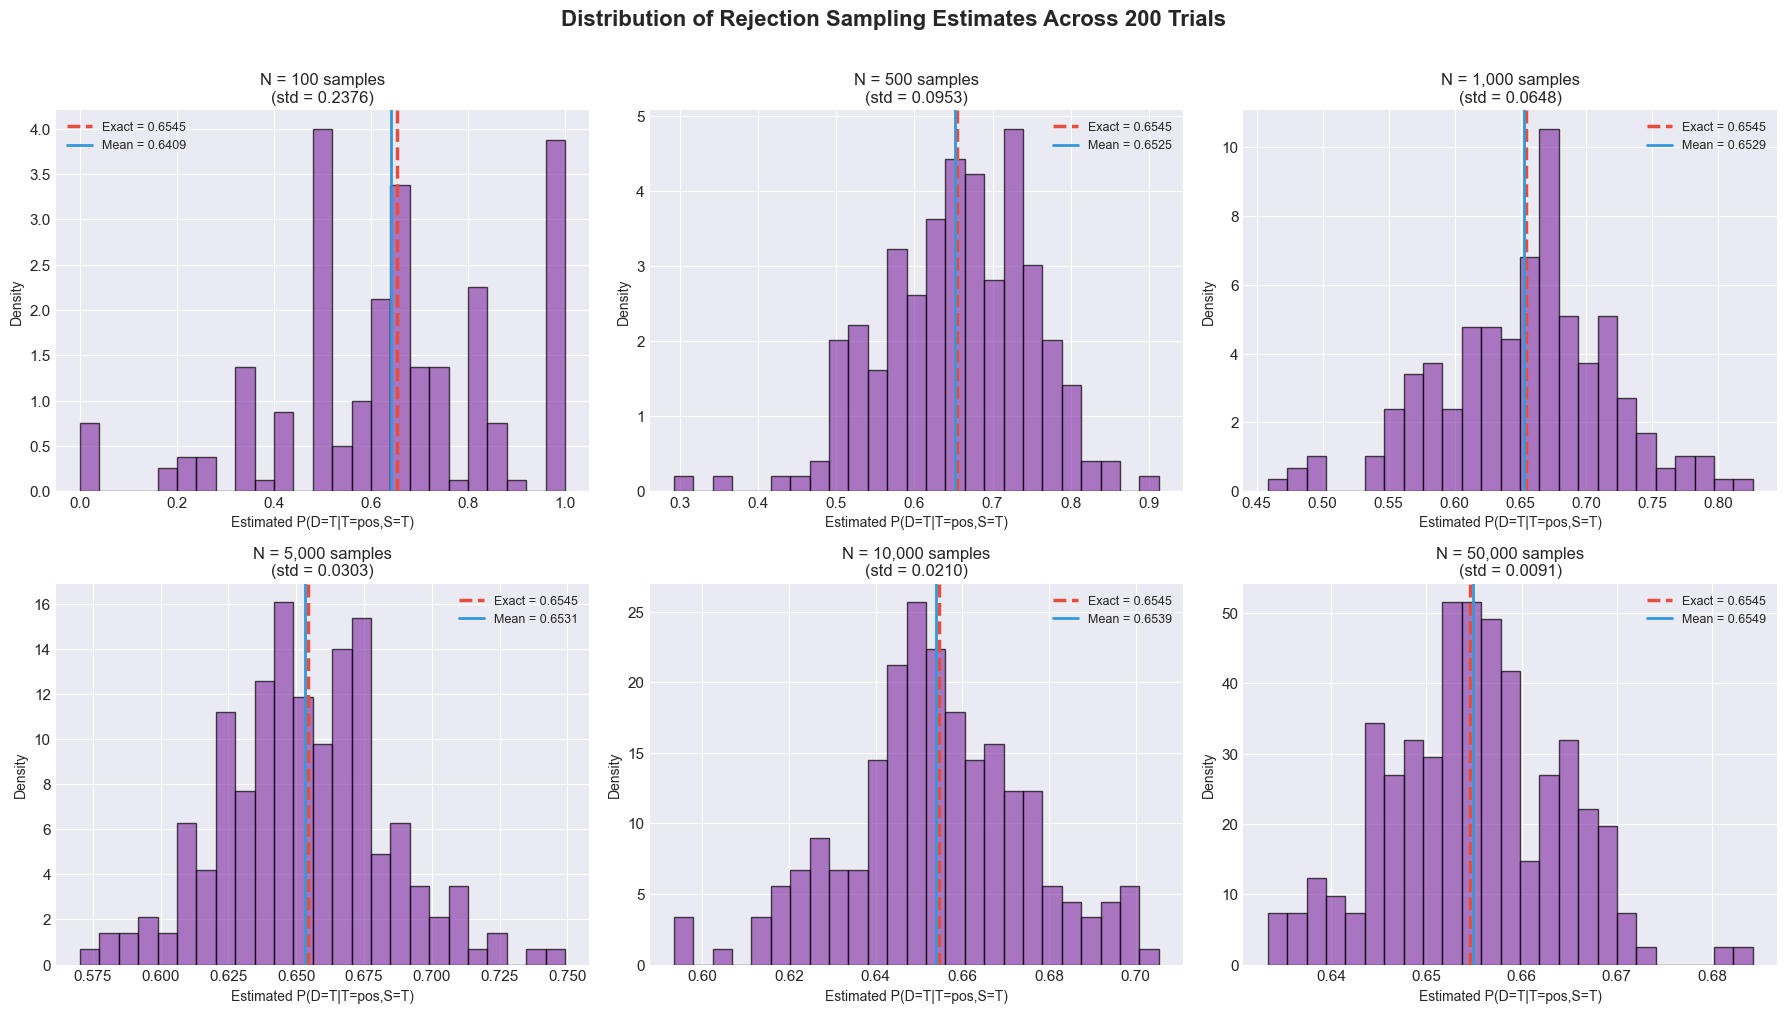

In [70]:
# =============================================================================
# Extended Simulation: Multiple Runs to Show Variance Reduction
# =============================================================================
# Run the sampling experiment 200 times at each sample size with different
# random seeds to observe how estimate variance decreases with more samples.

n_trials = 200  # Number of independent experiments per sample size
sample_sizes_extended = [100, 500, 1_000, 5_000, 10_000, 50_000]

trial_results = {}  # Dictionary to store results for each sample size

for n in sample_sizes_extended:
    estimates = []                          # Store estimated posterior from each trial
    for trial in range(n_trials):
        est, kept, _, _ = rejection_sampling(n, seed=trial)  # Different seed each trial
        if not np.isnan(est):               # Only include trials that kept at least 1 sample
            estimates.append(est)
    trial_results[n] = estimates            # Save all estimates for this sample size

# --- Visualization 1: Distribution of Estimates at Each Sample Size ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, n in enumerate(sample_sizes_extended):
    ax = axes[idx]
    data = trial_results[n]
    ax.hist(data, bins=25, color='#8E44AD', alpha=0.7, edgecolor='black', density=True)
    ax.axvline(exact_posterior, color='#e74c3c', lw=2.5, ls='--',
               label=f'Exact = {exact_posterior:.4f}')
    ax.axvline(np.mean(data), color='#3498db', lw=2, ls='-',
               label=f'Mean = {np.mean(data):.4f}')
    ax.set_title(f'N = {n:,} samples\n(std = {np.std(data):.4f})', fontsize=12)
    ax.set_xlabel('Estimated P(D=T|T=pos,S=T)', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(fontsize=9)

plt.suptitle('Distribution of Rejection Sampling Estimates Across 200 Trials',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

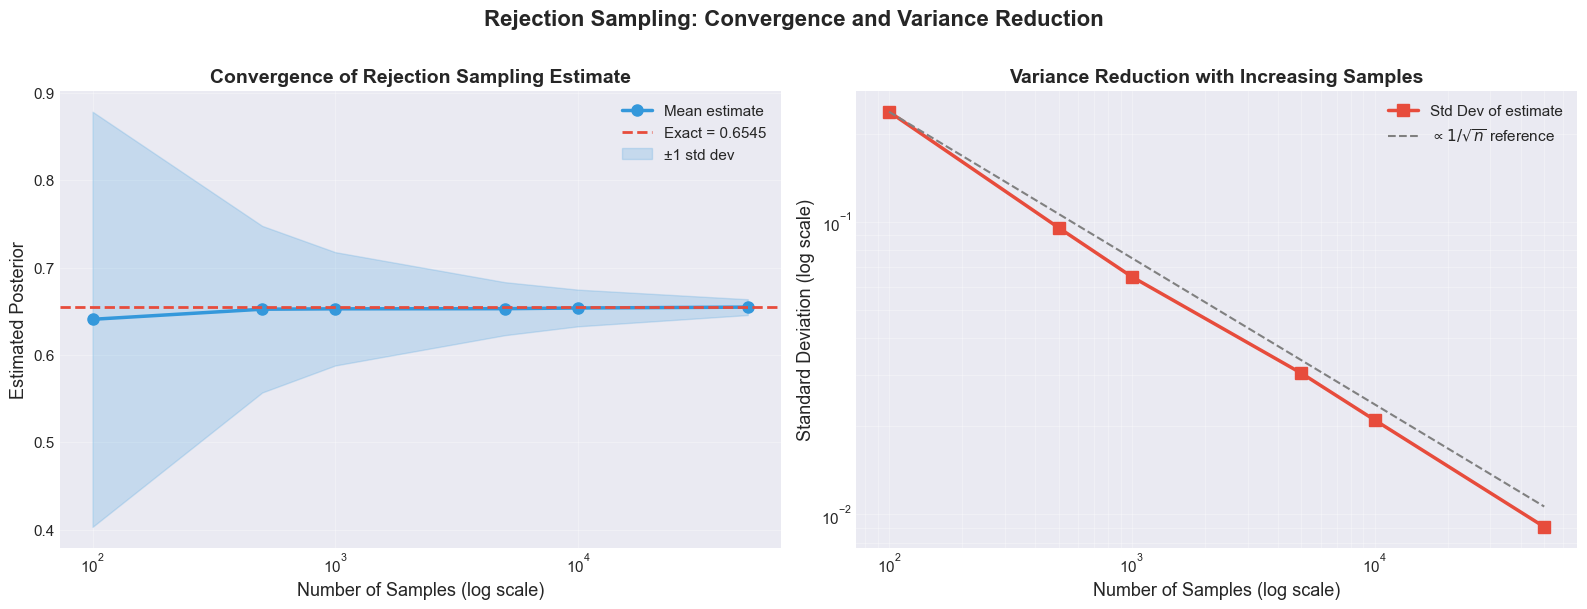


Summary: Estimate Statistics Across 200 Trials
   N Samples       Mean    Std Dev        Min        Max
----------------------------------------------------------------------
         100     0.6409     0.2376     0.0000     1.0000
         500     0.6525     0.0953     0.2917     0.9130
       1,000     0.6529     0.0648     0.4583     0.8261
       5,000     0.6531     0.0303     0.5703     0.7491
      10,000     0.6539     0.0210     0.5934     0.7053
      50,000     0.6549     0.0091     0.6334     0.6843
----------------------------------------------------------------------
       Exact     0.6545


In [71]:
# =============================================================================
# Visualization 2: Variance Reduction as Sample Size Increases
# =============================================================================
# Plot the standard deviation of the estimate vs. sample size to demonstrate
# the law of large numbers and convergence of Monte Carlo estimators.

means = [np.mean(trial_results[n]) for n in sample_sizes_extended]
stds = [np.std(trial_results[n]) for n in sample_sizes_extended]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left panel: Mean estimate vs sample size (convergence)
ax1.plot(sample_sizes_extended, means, 'o-', color='#3498db', lw=2.5,
         markersize=8, label='Mean estimate')
ax1.axhline(exact_posterior, color='#e74c3c', lw=2, ls='--',
            label=f'Exact = {exact_posterior:.4f}')
ax1.fill_between(sample_sizes_extended,
                 [m - s for m, s in zip(means, stds)],
                 [m + s for m, s in zip(means, stds)],
                 alpha=0.2, color='#3498db', label='±1 std dev')
ax1.set_xscale('log')
ax1.set_xlabel('Number of Samples (log scale)', fontsize=13)
ax1.set_ylabel('Estimated Posterior', fontsize=13)
ax1.set_title('Convergence of Rejection Sampling Estimate', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Right panel: Standard deviation vs sample size (variance reduction)
ax2.plot(sample_sizes_extended, stds, 's-', color='#e74c3c', lw=2.5,
         markersize=8, label='Std Dev of estimate')
# Theoretical 1/sqrt(n) curve for reference
theoretical_std = stds[0] * np.sqrt(sample_sizes_extended[0]) / np.sqrt(sample_sizes_extended)
ax2.plot(sample_sizes_extended, theoretical_std, '--', color='gray', lw=1.5,
         label=r'$\propto 1/\sqrt{n}$ reference')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Number of Samples (log scale)', fontsize=13)
ax2.set_ylabel('Standard Deviation (log scale)', fontsize=13)
ax2.set_title('Variance Reduction with Increasing Samples', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, which='both', alpha=0.3)

plt.suptitle('Rejection Sampling: Convergence and Variance Reduction',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Print summary table
print("\nSummary: Estimate Statistics Across 200 Trials")
print("=" * 70)
print(f"{'N Samples':>12} {'Mean':>10} {'Std Dev':>10} {'Min':>10} {'Max':>10}")
print("-" * 70)
for n in sample_sizes_extended:
    data = trial_results[n]
    print(f"{n:>12,} {np.mean(data):>10.4f} {np.std(data):>10.4f} "
          f"{np.min(data):>10.4f} {np.max(data):>10.4f}")
print("-" * 70)
print(f"{'Exact':>12} {exact_posterior:>10.4f}")

### Discussion: Sampling-Based Approximate Inference

**Why sampling is considered approximate inference.** Rejection sampling — and sampling-based methods in general — produce estimates of the true posterior rather than its exact value. Each run of the sampler generates a finite set of random samples from the joint distribution $P(D, T, S)$, and the posterior is estimated as the empirical fraction of accepted samples (those matching the evidence) in which the hypothesis holds. Because the samples are drawn randomly, any finite set of samples can only approximate the true distribution. Only in the limit as the number of samples approaches infinity does the estimate converge to the exact posterior by the law of large numbers. For any finite sample size, there is inherent randomness — two runs with different random seeds will produce slightly different estimates. This stochastic nature is what makes sampling methods "approximate" as opposed to exact inference algorithms like Variable Elimination or Junction Tree, which compute the mathematically precise answer through algebraic manipulations of the factor tables (Chen, 2026b).

**What happens to the variance of the estimate as sample size increases.** As the number of samples grows, the variance of the posterior estimate decreases. Specifically, for Monte Carlo estimators, the standard deviation of the estimate is proportional to $1/\sqrt{n}$, where $n$ is the effective number of accepted samples. This relationship is clearly visible in the variance reduction plot above, where the standard deviation across 200 independent trials drops steadily as the sample size increases from 100 to 50,000. At 100 samples, the estimates are spread broadly and individual runs may produce values far from the true posterior. At 10,000 samples, the estimates cluster tightly around the exact value. This convergence behavior is a direct consequence of the central limit theorem applied to the sample mean (Russell & Norvig, 2021, Chapter 13). However, to halve the standard error, we must quadruple the sample size, which means achieving very high precision through sampling alone can be expensive.

**Why this approach scales better than exact inference in large networks.** Exact inference algorithms like Variable Elimination have time complexity that is exponential in the treewidth of the Bayesian network — $O(n \cdot k^{w+1})$ — meaning that densely connected networks with high treewidth become computationally intractable. In contrast, rejection sampling only requires the ability to draw forward samples from the generative model, which involves sampling each variable from its conditional distribution given its parents. This forward sampling step is $O(n)$ per sample regardless of the network's structure, because each variable is sampled once from a local conditional distribution. The total cost is $O(n \cdot N_{\text{samples}})$, which is linear in both the network size and the number of samples, with no exponential dependence on treewidth. This makes sampling approaches feasible for large, complex networks where exact methods are prohibitively expensive (Russell & Norvig, 2021, Chapter 13).

**One limitation of rejection sampling.** The primary limitation of rejection sampling is its low acceptance rate when the evidence is unlikely under the prior. In our example, the probability of the evidence $P(T = \text{positive}, S = \text{true}) \approx 0.055$, meaning that only about 5.5% of generated samples are accepted. This wastes approximately 94.5% of the computational effort on samples that are immediately discarded. In networks where the evidence is even more unlikely — for example, observing a rare combination of symptoms — the acceptance rate can drop to fractions of a percent, making rejection sampling impractically inefficient. This is why more sophisticated sampling methods such as likelihood weighting and Markov chain Monte Carlo (MCMC) were developed: they avoid outright rejection and instead weight or propose samples in ways that focus computational effort on the high-probability regions of the sample space consistent with the observed evidence (Russell & Norvig, 2021, Chapter 13).

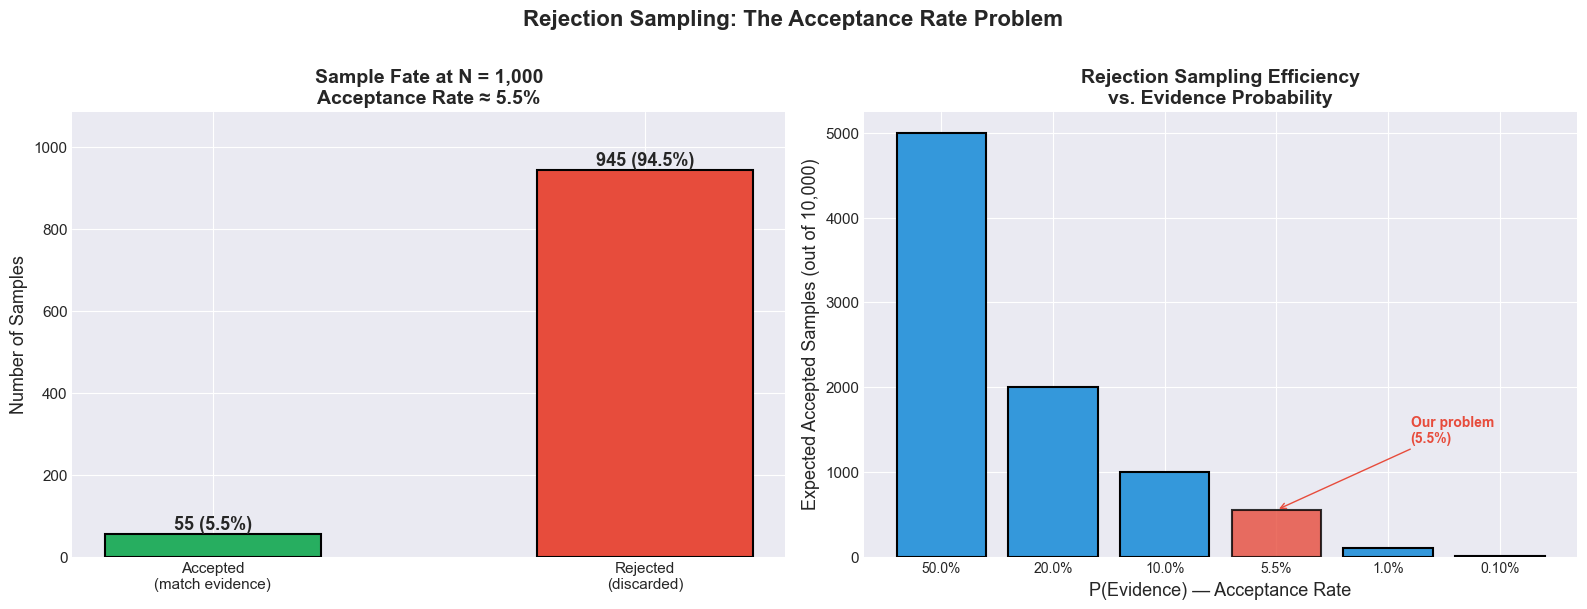


In our problem, only ~5.5% of samples are accepted.
At N=10,000 total samples, we expect ~550 accepted samples.
This illustrates why rejection sampling becomes inefficient for rare evidence.
More advanced methods (likelihood weighting, MCMC) address this limitation.


In [72]:
# =============================================================================
# Visualization: Acceptance Rate and Efficiency of Rejection Sampling
# =============================================================================
# Demonstrate the key limitation: most samples are rejected when evidence
# probability is low.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Panel 1: Sample Fate at N=1000 ---
n_demo = 1000
est, kept, d_true, kept_d = rejection_sampling(n_demo, seed=42)
rejected = n_demo - kept

categories = ['Accepted\n(match evidence)', 'Rejected\n(discarded)']
counts = [kept, rejected]
colors = ['#27ae60', '#e74c3c']

bars = ax1.bar(categories, counts, color=colors, edgecolor='black', lw=1.5, width=0.5)
for bar, count in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{count} ({count/n_demo:.1%})', ha='center', fontsize=13, fontweight='bold')

ax1.set_ylabel('Number of Samples', fontsize=13)
ax1.set_title(f'Sample Fate at N = {n_demo:,}\nAcceptance Rate ≈ {kept/n_demo:.1%}',
              fontsize=14, fontweight='bold')
ax1.set_ylim(0, max(counts) * 1.15)

# --- Panel 2: What if evidence probability were different? ---
evidence_probs = [0.5, 0.2, 0.1, 0.055, 0.01, 0.001]
n_total = 10000
effective_samples = [n_total * p for p in evidence_probs]

ax2.bar(range(len(evidence_probs)), effective_samples, color='#3498db',
        edgecolor='black', lw=1.5)
ax2.set_xticks(range(len(evidence_probs)))
ax2.set_xticklabels([f'{p:.1%}' if p >= 0.01 else f'{p:.2%}' for p in evidence_probs],
                     fontsize=10)
ax2.set_xlabel('P(Evidence) — Acceptance Rate', fontsize=13)
ax2.set_ylabel(f'Expected Accepted Samples (out of {n_total:,})', fontsize=13)
ax2.set_title('Rejection Sampling Efficiency\nvs. Evidence Probability',
              fontsize=14, fontweight='bold')

# Highlight our problem's acceptance rate
our_idx = 3  # index for 0.055
ax2.patches[our_idx].set_facecolor('#e74c3c')
ax2.patches[our_idx].set_alpha(0.8)
ax2.annotate('Our problem\n(5.5%)', xy=(our_idx, effective_samples[our_idx]),
             xytext=(our_idx + 1.2, effective_samples[our_idx] + 800),
             fontsize=10, fontweight='bold', color='#e74c3c',
             arrowprops=dict(arrowstyle='->', color='#e74c3c'))

plt.suptitle('Rejection Sampling: The Acceptance Rate Problem',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"\nIn our problem, only ~{P_evidence:.1%} of samples are accepted.")
print(f"At N=10,000 total samples, we expect ~{10000 * P_evidence:.0f} accepted samples.")
print(f"This illustrates why rejection sampling becomes inefficient for rare evidence.")
print(f"More advanced methods (likelihood weighting, MCMC) address this limitation.")

---
## References

Chen, S. (2026a). *Module 5 – Lecture 5A: From deterministic optimization to uncertainty* [Lecture notes]. Johns Hopkins University, EN.705.623 AI Algorithm Design and Analysis. https://jhu.edu

Chen, S. (2026b). *Module 5 – Lecture 5B: Exact inference algorithms* [Lecture notes]. Johns Hopkins University, EN.705.623 AI Algorithm Design and Analysis. https://jhu.edu

Chen, S. (2026c). *Module 5 – Lecture 5C: Approximate inference algorithms* [Lecture notes]. Johns Hopkins University, EN.705.623 AI Algorithm Design and Analysis. https://jhu.edu

Koller, D., & Friedman, N. (2009). *Probabilistic graphical models: Principles and techniques*. MIT Press. https://mitpress.mit.edu/books/probabilistic-graphical-models

Murphy, K. P. (2012). *Machine learning: A probabilistic perspective*. MIT Press. https://probml.github.io/pml-book/

Russell, S. J., & Norvig, P. (2021). *Artificial intelligence: A modern approach* (4th ed.). Pearson. https://aima.cs.berkeley.edu/

Pearl, J. (1988). *Probabilistic reasoning in intelligent systems: Networks of plausible inference*. Morgan Kaufmann. https://doi.org/10.1016/C2009-0-27609-4